# Open Jackson Network Model from JSON

In this notebook we will create a `ciw` network model from a specification in a JSON file.

The model represents a a classic queuing network problem that can be formulated as an Open Jackson Network.

<img src="img/jackson_network_sketch.png" alt="jackson_network" width="600"/>




## 1. Imports

### 1.1 `json2ciw` imports

**We will use:**

*  `load_call_centre_model` function that loads the built in urgent care call centre JSON file.
*  `ProcessModel`: a `pydantic` schema that provides automatic validation of the JSON.
* `CiwConverter` that accepts a valid `ProcessModel` that represents a DES model and returns a `ciw` parameter `dict`.
* `multiple_replications`:runs the network model and results a `Dataframe` of replication results.
* `summarise_results`: provides a formatted table of mean results for each node in the network.
* `tidy_to_wide_format`: the results from `multiple_replications` are returned in tidy (stacked row) format. This function converts into wide format i.e. each column is a performance measure.
* `create_user_filtered_hist` generates a interactive plotly chart to view replications for each performance measure. It requires replication data in **wide** format.

In [ ]:
from json2ciw.datasets import load_jackson_network_model
from json2ciw.engine import (
    CiwConverter,
    multiple_replications
)
from json2ciw.results import (
    summarise_results, 
    create_user_filtered_hist,
    tidy_to_wide_format
)

from json2ciw.schema import ProcessModel

### 1.2 Other imports

In [2]:
import ciw
import statistics
from IPython.display import JSON
from rich import print

## 2. Load JSON

In [ ]:
json_network = load_jackson_network_model()

display as collapsible JSON.  Expand to view the details.

In [ ]:
JSON(json_network)

<IPython.core.display.JSON object>

## 3. Convert to a ProcessModel

A `ProcessModel` is a `pydantic` schema. It is independent of `ciw`. This early version will automatically validate that the JSON file is correct and that all transitions add up to 1.0 when it is created.  

In [ ]:
model_instance = ProcessModel(**json_network)

Transitions sum to 1.0 for all activities.


The contents of the process model can be manually inspected by a developer as follows:

In [6]:
print(model_instance)

ProcessModel(
    name='Call Handling Process',
    description='Discrete Event Simulation of a Patient call handling process.',
    activities=[
        Activity(
            name='Call Triage',
            type='activity',
            resource=Resource(name='Operator', capacity=13),
            service_distribution=Distribution(
                type='triangular',
                parameters={'min': 5.0, 'mode': 7.0, 'max': 10.0}
            ),
            arrival_distribution=Distribution(type='exponential', parameters={'mean': 0.6})
        ),
        Activity(
            name='Nurse Consultation',
            type='activity',
            resource=Resource(name='Nurse', capacity=9),
            service_distribution=Distribution(type='uniform', parameters={'min': 10.0, 'max': 20.0}),
            arrival_distribution=None
        )
    ],
    transitions=[
        Transition(source='Call Triage', target='Nurse Consultation', probability=0.4),
        Transition(source='Call Triage', target='Exit', probability=0.6),
        Transition(source='Nurse Consultation', target='Exit', probability=1.0)
    ]
)

In [7]:
model_instance.display_diagram()

```mermaid
graph TD
    %% Call Handling Process: Discrete Event Simulation of a Patient call handling process.
    Arrivals_Call_Triage("Time between arrivals<br/>Exponential(mean=0.6)")
    Call_Triage["Call Triage<br/>Tri(5.0, 7.0, 10.0)"]
    Nurse_Consultation["Nurse Consultation<br/>Uniform(10.0, 20.0)"]
    Resource_Operator(("Operator<br/>(13)"))
    Resource_Nurse(("Nurse<br/>(9)"))
    Exit(["Exit"])

    Arrivals_Call_Triage --> Call_Triage
    Resource_Operator -.Seize.-> Call_Triage
    Call_Triage -.Release.-> Resource_Operator
    Resource_Nurse -.Seize.-> Nurse_Consultation
    Nurse_Consultation -.Release.-> Resource_Nurse
    Call_Triage -->|40%| Nurse_Consultation
    Call_Triage -->|60%| Exit
    Nurse_Consultation --> Exit
```

## 3. Convert to a `ciw` Network Model

In [8]:
adapter = CiwConverter(model_instance)
network_params = adapter.generate_params()

The variable `network_params` is a python `dict` that contains all the parameters that `ciw` requires for a very simple queuing model. This can be passed as keyword args to the `ciw.create_network` function.

In [9]:
network_params

{'number_of_servers': [13, 9],
 'arrival_distributions': [Exponential(rate=1.6666666666666667), None],
 'service_distributions': [Triangular(lower=5.0, mode=7.0, upper=10.0),
  Uniform(lower=10.0, upper=20.0)],
 'routing': [[0.0, 0.4], [0.0, 0.0]]}

In [10]:
# we use ciw's native `create_network` method
network = ciw.create_network(**network_params)
print(type(network))

<class 'ciw.network.Network'>

In [11]:
# Run a quick simulation to verify it works without crashing...
sim = ciw.Simulation(network)
sim.simulate_until_max_time(50)
print("Quick simulation run worked!")

Quick simulation run worked!

## 4. Run the model for multiple replications

The `multiple_replications` function returns a `DataFrame` that contains one row per activity per replication.  So if there are two nodes there are two rows for each replication.

In [12]:
# Run replications with activity/resource names
df_reps = multiple_replications(
    network, 
    model_instance, 
    num_reps=100, 
    runtime=2880,
    warmup=1440,
    n_jobs=-1 # parallel reps
)

df_reps.head()

,rep,node_id,activity_name,resource_name,resource_capacity,arrivals,mean_wait,mean_service,utilisation,mean_Lq
0,0,1,Call Triage,Operator,13,2409,2.543220,7.309819,95.129252,4.254594
1,0,2,Nurse Consultation,Nurse,9,765,206.954675,14.990006,99.164671,109.944671
2,1,1,Call Triage,Operator,13,2370,2.795481,7.321618,93.117043,4.600896
3,1,2,Nurse Consultation,Nurse,9,773,224.244232,14.981693,99.525047,120.375549
4,2,1,Call Triage,Operator,13,2426,4.816395,7.323897,95.099958,8.114287


Filter the nodes with the usual `pandas` syntax

In [ ]:
# df_reps.loc[df_reps['activity_name'] == "Call Triage"].head(3)

,rep,node_id,activity_name,resource_name,resource_capacity,arrivals,mean_wait,mean_service,utilisation,mean_Lq
0,0,1,Call Triage,Operator,13,2409,2.543220,7.309819,95.129252,4.254594
2,1,1,Call Triage,Operator,13,2370,2.795481,7.321618,93.117043,4.600896
4,2,1,Call Triage,Operator,13,2426,4.816395,7.323897,95.099958,8.114287


## 5. Summarise results

If needed there is a built in function to create a `DataFrame` that contains a mean summary of all metrics across the nodes.

In [14]:
# Get summary table
summary = summarise_results(df_reps)
summary.round(1)

activity,Metric,Call Triage (Operator),Nurse Consultation (Nurse)
0,Mean arrivals,2386.3,763.6
1,Mean waiting time,4.0,216.1
2,Mean service time,7.3,15.0
3,Mean utilisation,93.9,99.3
4,Mean queue length,6.6,113.7


In [15]:
wide = tidy_to_wide_format(df_reps)
wide.head()

,arrivals [Call Triage],arrivals [Nurse Consultation],mean_wait [Call Triage],mean_wait [Nurse Consultation],mean_service [Call Triage],mean_service [Nurse Consultation],utilisation [Call Triage],utilisation [Nurse Consultation],mean_Lq [Call Triage],mean_Lq [Nurse Consultation]
rep,,,,,,,,,,
0,2409,765,2.543220,206.954675,7.309819,14.990006,95.129252,99.164671,4.254594,109.944671
1,2370,773,2.795481,224.244232,7.321618,14.981693,93.117043,99.525047,4.600896,120.375549
2,2426,761,4.816395,228.917962,7.323897,14.812186,95.099958,99.342764,8.114287,120.976784
3,2308,725,3.124735,243.422767,7.351322,15.043528,92.053435,99.140463,5.008256,122.556602
4,2449,752,4.211408,246.921582,7.334381,14.992293,94.982781,99.548895,7.162318,128.947937


In [16]:
fig = create_user_filtered_hist(wide)

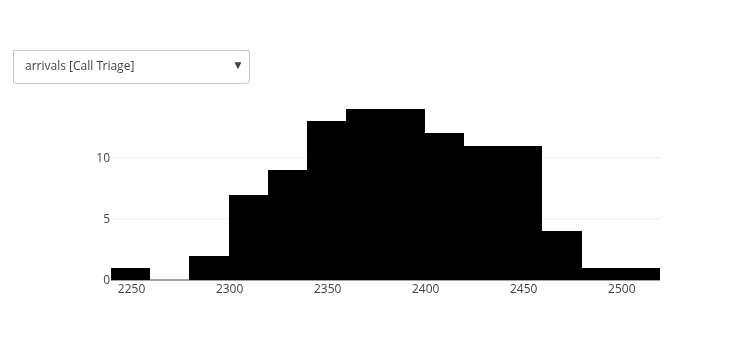

In [17]:
fig.show()